# Preliminary steps

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
# adjust
path = 'NLP/project'

os.chdir(f'/content/drive/MyDrive/{path}')
os.getcwd()

'/content/drive/MyDrive/NLP/project'

You may want to load the already restructured data directly for convenience, in that case you can skip the dataset download and restructuring section

In [ ]:
%pip install datasets
!pip install nltk
!pip install wordninja
!pip install textacy --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for wordninja: filename=wordninja-2.0.0-py3-none-any.whl size=541530 sha256=5629cf1805576bcab2b89ddd16e3b601ce21db99c817504283d05bfb56cfc983
  Stored in directory: /root/.cache/pip/wheels/e6/66/9c/712044a983337f5d44f90abcd244bd4b8ad28ee64750404b50
Successfully built wordninja
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.6/321.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.9/356.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.1 MB/s eta 0:00:00


In [ ]:
#importing necessary libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import Counter
import numpy as np
from nltk import pos_tag
from scipy.stats import pearsonr
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import plotly.graph_objects as go
import plotly.express as px
import wordninja
from cleantext import clean
import textacy.preprocessing.replace as repl

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
try:
    nltk.data.find('corpora/words')
except LookupError:
    nltk.download('words')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Loading and restructuring the dataset

In [ ]:
from datasets import load_dataset, concatenate_datasets, DatasetDict

# Load the RACE dataset, specifying the desired configuration
dataset_high = load_dataset("ehovy/race", "high") # Choose 'all', 'high', or 'middle'
dataset_middle = load_dataset("ehovy/race", "middle") # Choose 'all', 'high', or 'middle

In [ ]:
# Build a the complete dataset by concatenation
dataset_complete = DatasetDict({
    split: concatenate_datasets([
        dataset_high[split],
        dataset_middle[split]
    ])
    for split in ["train", "validation", "test"]
})

In [ ]:
def create_article_mapping(dataset_complete):
    """Create a consistent article to ID mapping for the complete dataset"""
    article_to_id = {}
    for split in ['train', 'validation', 'test']:
      for example in dataset_complete[split]:
          article = example['article']
          if article not in article_to_id:
              article_to_id[article] = len(article_to_id)
    return article_to_id

def restructure_dataset_with_mapping(dataset, article_to_id):
    """
    Restructures dataset using pre-defined article IDs
    Returns dictionary with article_id as keys
    """
    restructured = {}

    for example in dataset:
        article = example['article']
        article_id = article_to_id[article]

        question_info = {
            'example_id': example['example_id'],
            'question': example['question'],
            'options': example['options'],
            'answer': example['answer']
        }

        if article_id not in restructured:
            restructured[article_id] = {
                'article_text': article,
                'questions': []
            }

        restructured[article_id]['questions'].append(question_info)

    return restructured

# 1) Build the unified mapping once (from dataset_complete = high+middle):
article_to_id = create_article_mapping(dataset_complete)

# 2) Restructure only the middle & high splits:
middle_dict = {
    split: restructure_dataset_with_mapping(dataset_middle[split], article_to_id)
    for split in ['train', 'validation', 'test']
}
high_dict = {
    split: restructure_dataset_with_mapping(dataset_high[split], article_to_id)
    for split in ['train', 'validation', 'test']
}

# whenever the complete dict is needed you can just build it like so:
"""
# 3) Build “all” by merging high + high:
complete_dict = {
    split: {**high_dict[split], **middle_dict[split]}
    for split in ['train', 'validation', 'test']
}
"""

# Final nested dict:
dataset_dict = {
    'middle': middle_dict,
    'high':   high_dict,
    #'all':    complete_dict
}


In [ ]:
# Choose a save path/filename inside your mounted Google Drive folder
save_path = "race_restructured.pkl"

# Save as pickle
with open(save_path, "wb") as f:
    pickle.dump(dataset_dict, f)


print(f"Dataset saved to: {os.path.join(os.getcwd(), save_path)}")

Dataset saved to: /content/drive/MyDrive/NLP/project/race_restructured.pkl


# Splitninja modified

In [ ]:
import re
import wordninja

def smart_split(text, min_word_length=15):
    # 1) Normalize line breaks
    text = text.replace('.\n', ' . ')
    text = text.replace('\n', ' . ')

    # 2) Separate long words+punctuation from next CapitalizedWord
    text = re.sub(
        r'(\b\w{3,})([.!?])\s*(\b[A-Z]\w{2,})',
        r'\1 \2 \3',
        text
    )

    # 3) Tokenize into:
    #    – pure‐alpha words
    #    – numeric runs (digits with optional /, :, or . separators)
    #    – everything else (one char at a time)
    tokens = re.findall(
        r'([A-Za-z]+|\d+(?:[\/:\.,]\d+)*|[^A-Za-z0-9])',
        text
    )

    # 4) Rebuild, splitting only pure-alpha tokens via wordninja:
    processed = []
    for tok in tokens:
        if tok.isalpha():
            processed.extend(wordninja.split(tok))
        else:
            if tok != ' ':
                processed.append(tok)

    text = " ".join(processed)

    # 5) Clean up spaces before punctuation
    text = re.sub(r'(\w)\s+([.?!,;:—…])', r'\1\2', text)

In [ ]:
def apply_wordninja_splitting(data,
                              fields_to_process={'article_text'},
                              char_threshold=25):
    """
    Recursively applies smart_split (wordninja) to specified text fields in a nested structure,
    but only when those fields contain at least one “long” word (> char_threshold)
    made up of [A-Za-z'",-] characters. Also performs general cleanup regexes first.

    :param data:          Nested dict/list structure to process.
    :param fields_to_process: Set of keys whose string values should be tested+split.
    :param char_threshold:     Length threshold above which we split.
    :returns: Updated data in-place.
    """
    count = 0

    def _recurse(obj, path=()):
        nonlocal count

        if isinstance(obj, dict):
            for key, val in obj.items():
                # If this is one of our target fields, and is a string
                if key in fields_to_process and isinstance(val, str):
                    text = val
                    # 1) cleanup runs
                    text = re.sub(r'([.\*-])\1+', r'\1', text)
                    text = re.sub(
                        r"([A-Za-z])\s+'\s+(am|re|s|t|nt|ve|ll|d)\b",
                        r"\1'\2",
                        text
                    )

                    # 2) scan for any long word
                    long_word = None
                    # splitting also on / . and , avoids urls and word,word,word pattern

                    for w in re.split(r'[ ,/\.]', text):
                        if len(w) > char_threshold and re.match(r"^[A-Za-z',\"-]+$", w):
                            long_word = w
                            break

                    # 3) if found, apply splitting + second cleanup
                    if long_word:
                        count += 1
                        print(f"Path: {'/'.join(path+[key])}, Long word: {long_word}")
                        text = smart_split(text)
                        text = re.sub(
                            r"([A-Za-z])\s+'\s+(am|re|s|t|nt|ve|ll|d)\b",
                            r"\1'\2",
                            text
                        )
                    # assign back (split or just cleaned)
                    obj[key] = text

                # otherwise recurse deeper
                else:
                    _recurse(val, path + (key,))

        elif isinstance(obj, list):
            for idx, item in enumerate(obj):
                _recurse(item, path + (f"[{idx}]",))

    _recurse(data)
    print(f"Total splits applied: {count}")
    return data



In [ ]:
dataset_dict = apply_wordninja_splitting(dataset_dict, {'article_text', 'question'}, char_threshold=25)
dataset_dict = apply_wordninja_splitting(datset_dict, {'question'}, char_threshold=18)
dataset_dict = apply_wordninja_splitting(dataset_dict, {'options'}, char_threshold=12)

# Word Embeddings (Word2Vec)


## preliminary steps

In [ ]:
import re
url_re = re.compile(r'''
    (?:                                  # no capture, choose one branch
      (?i:                               # 1)
        https?\s*:\s*(?:/\s*){2}         #   http://  or  https://
      | www\s*\.\s*                     # 2) www. prefix
      )
      (?:                                # domain = one or more “words”
        [A-Za-z0-9-]+
        (?:[\s\.]+[A-Za-z0-9-]+)*        #   separated by spaces or dots
      )
      (?:\s*\.\s*                        # final “.TLD”
         (?:Com|Org|[a-z]{2,6})             #   either literal “Com”,"Org" or 2–6 lowercase letters
      )
    )
    (?:\s*[/?#]\s*\S*)?                  # optional path/query, allowing space before /
    (?![a-z0-9])                      # don’t run into following word
''', re.VERBOSE)

email_re = r"[\w\.-]+@([\w-]+\.)+[\w-]{2,4}"

phone_re = r"[\+]?[(]?[0-9]{3}[)]?[-\s\.]*[(]?[0-9]{3}[)]?[-\s\.]*[0-9]{4,6}"


def preprocess_text(text):
    # Remove emails
    text = re.sub(email_re, '', text)
    # Remove URLs
    text = re.sub(url_re, '', text)
    # remove phone
    text = re.sub(phone_re, '', text)
    # Remove newline characters
    text = text.replace('\n', '. ')
    text = text.replace('.\n', '. ')
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

articles_cleaned = df_docs['article'].apply(preprocess_text).tolist()
print(len(articles_cleaned))
sentences = [sentence for article in articles_cleaned for sentence in article.split('[?!.]\s')]
print(len(sentences))
sentences[:3]

In [ ]:
from pandas.core.common import flatten

sentences = list(flatten(sentences))
sentences[:20]

['Last week I talked with some of my students about what they wanted to do after they graduated, and what kind of job prospects they thought they had.. Given that I teach students who are training to be doctors, I was surprised do find that most thought that they would not be able to get the jobs they wanted without "outside help". "What kind of help is that?" I asked, expecting them to tell me that they would need a or family friend to help them out.. "Surgery ," one replied.. I was pretty alarmed by that response. It seems that the graduates of today are increasingly willing to go under the knife to get ahead of others when it comes to getting a job .. One girl told me that she was considering surgery to increase her height. "They break your legs, put in special extending screws, and slowly expand the gap between the two ends of the bone as it re-grows, you can get at least 5 cm taller!". At that point, I was shocked. I am short, I can\'t deny that, but I don\'t think I would put mys

In [ ]:
tokenized_sentences = [re.sub('\W', ' ', sentence).lower().split() for sentence in sentences]
# remove sentences that are only 1 word long
tokenized_sentences = [sentence for sentence in tokenized_sentences if len(sentence) > 1]

for sentence in tokenized_sentences[:10]:
    print(sentence)

['last', 'week', 'i', 'talked', 'with', 'some', 'of', 'my', 'students', 'about', 'what', 'they', 'wanted', 'to', 'do', 'after', 'they', 'graduated', 'and', 'what', 'kind', 'of', 'job', 'prospects', 'they', 'thought', 'they', 'had', 'given', 'that', 'i', 'teach', 'students', 'who', 'are', 'training', 'to', 'be', 'doctors', 'i', 'was', 'surprised', 'do', 'find', 'that', 'most', 'thought', 'that', 'they', 'would', 'not', 'be', 'able', 'to', 'get', 'the', 'jobs', 'they', 'wanted', 'without', 'outside', 'help', 'what', 'kind', 'of', 'help', 'is', 'that', 'i', 'asked', 'expecting', 'them', 'to', 'tell', 'me', 'that', 'they', 'would', 'need', 'a', 'or', 'family', 'friend', 'to', 'help', 'them', 'out', 'surgery', 'one', 'replied', 'i', 'was', 'pretty', 'alarmed', 'by', 'that', 'response', 'it', 'seems', 'that', 'the', 'graduates', 'of', 'today', 'are', 'increasingly', 'willing', 'to', 'go', 'under', 'the', 'knife', 'to', 'get', 'ahead', 'of', 'others', 'when', 'it', 'comes', 'to', 'getting', '

## Model Training

In [ ]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

class EpochLogger(CallbackAny2Vec):
    '''Callback to log information about training'''

    def __init__(self):
        self.epoch = 0

    def on_epoch_begin(self, model):
        print(f"Epoch #{self.epoch} start")

    def on_epoch_end(self, model):
        print(f"Epoch #{self.epoch} end")
        self.epoch += 1

# Initialize the callback
epoch_logger = EpochLogger()

# Train the Word2Vec model with the callback
model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=50,
    min_count=5,
    window=10,
    workers=4,
    callbacks=[epoch_logger]
)


Epoch #0 start
Epoch #0 end
Epoch #1 start
Epoch #1 end
Epoch #2 start
Epoch #2 end
Epoch #3 start
Epoch #3 end
Epoch #4 start
Epoch #4 end


In [ ]:
len(model.wv)

25955

## uncovering word-level relationships

In [ ]:
term ='environment'

model.wv.most_similar(term)

[('resources', 0.7764384746551514),
 ('resource', 0.7190690040588379),
 ('sustainable', 0.7105017900466919),
 ('demands', 0.6722909808158875),
 ('communities', 0.6691863536834717),
 ('biodiversity', 0.6678361296653748),
 ('ecological', 0.666018545627594),
 ('environmental', 0.6600812077522278),
 ('solutions', 0.6588603258132935),
 ('environments', 0.6511269211769104)]

In [ ]:
term = 'democracy'

model.wv.most_similar(term)

[('contributions', 0.7766295075416565),
 ('preservation', 0.7747161984443665),
 ('pr', 0.7650051712989807),
 ('revolutionary', 0.7590325474739075),
 ('representation', 0.7559933066368103),
 ('distinguished', 0.7558971643447876),
 ('sino', 0.7526567578315735),
 ('tcm', 0.7524153590202332),
 ('persuasion', 0.7496934533119202),
 ('democratic', 0.7495113611221313)]

In [ ]:
term = 'china'
model.wv.most_similar(term)

[('mainland', 0.7815131545066833),
 ('japan', 0.7615446448326111),
 ('chinese', 0.7472635507583618),
 ('russia', 0.7424290776252747),
 ('nation', 0.7338283658027649),
 ('taiwan', 0.7034121751785278),
 ('thailand', 0.7025784850120544),
 ('asia', 0.6976500153541565),
 ('reform', 0.6853789687156677),
 ('exports', 0.6830196976661682)]

In [ ]:
term = 'mainland'
model.wv.most_similar(term)

[('taiwan', 0.8742483854293823),
 ('netherlands', 0.8305874466896057),
 ('singapore', 0.8131567239761353),
 ('cambodia', 0.7995209097862244),
 ('japan', 0.7903361320495605),
 ('guangdong', 0.7890262007713318),
 ('thailand', 0.7866135239601135),
 ('fujian', 0.7827993631362915),
 ('china', 0.7815131545066833),
 ('switzerland', 0.7813818454742432)]

In [ ]:
term = 'italy'
model.wv.most_similar(term)

[('spain', 0.9355541467666626),
 ('france', 0.9238387942314148),
 ('ireland', 0.8628278374671936),
 ('morocco', 0.856774628162384),
 ('portugal', 0.8470819592475891),
 ('europe', 0.8458232283592224),
 ('mexico', 0.8445810079574585),
 ('egypt', 0.8432140350341797),
 ('india', 0.8392709493637085),
 ('belgium', 0.8381503224372864)]

In [ ]:
term = 'germany'
model.wv.most_similar(term)

[('italian', 0.827725350856781),
 ('dutch', 0.8268539309501648),
 ('scottish', 0.762063205242157),
 ('spanish', 0.7556493878364563),
 ('french', 0.7546578049659729),
 ('russian', 0.7414990663528442),
 ('1843', 0.737040102481842),
 ('latin', 0.7251148819923401),
 ('1860s', 0.7222200036048889),
 ('patron', 0.7128103971481323)]

In [ ]:
term = 'russia'
model.wv.most_similar(term)

[('republic', 0.8716553449630737),
 ('japan', 0.8577644228935242),
 ('switzerland', 0.8559234142303467),
 ('brazil', 0.8514019250869751),
 ('vietnam', 0.8497235774993896),
 ('sweden', 0.8414783477783203),
 ('taiwan', 0.8412132859230042),
 ('norway', 0.8368993401527405),
 ('cuba', 0.8144669532775879),
 ('democratic', 0.8082297444343567)]

In [ ]:
term = 'sovereignty'
model.wv.most_similar(term)

[('demonstrations', 0.8353773951530457),
 ('domestically', 0.8241971731185913),
 ('consensus', 0.8207849264144897),
 ('anc', 0.8163542747497559),
 ('288', 0.8130234479904175),
 ('brotherhood', 0.8106955885887146),
 ('occurrences', 0.8006118535995483),
 ('tabb', 0.7995049953460693),
 ('mila', 0.7984246611595154),
 ('huawei', 0.7982578277587891)]

In [ ]:
term = 'trump'
model.wv.most_similar(term)

[('republican', 0.8614423274993896),
 ('vladimir', 0.8301828503608704),
 ('jinping', 0.8283683657646179),
 ('clinton', 0.8219013214111328),
 ('raymond', 0.818210244178772),
 ('longtime', 0.8181419372558594),
 ('presidency', 0.817548394203186),
 ('putin', 0.8164105415344238),
 ('clezio', 0.8099057078361511),
 ('chairman', 0.8095476627349854)]

In [ ]:
term = 'putin'
model.wv.most_similar(term)

[('vladimir', 0.9148184061050415),
 ('jinping', 0.8447864055633545),
 ('prime', 0.8419925570487976),
 ('jintao', 0.8402242064476013),
 ('jiabao', 0.8340128064155579),
 ('qian', 0.8312210440635681),
 ('clinton', 0.8183923363685608),
 ('trump', 0.8164104223251343),
 ('chairman', 0.8155210018157959),
 ('deng', 0.8136618733406067)]

In [ ]:
term = 'allies'
model.wv.most_similar(term)

[('distrust', 0.7994890809059143),
 ('vikings', 0.7837837934494019),
 ('hooke', 0.7798570990562439),
 ('1822', 0.7777422070503235),
 ('nato', 0.7776151895523071),
 ('guthrie', 0.76982581615448),
 ('lima', 0.7650429606437683),
 ('attribute', 0.7640810012817383),
 ('clashes', 0.7632002830505371),
 ('magnon', 0.7628315687179565)]

In [ ]:
term22 = 'warcraft'
model.wv.most_similar(term)

[('healy', 0.8014403581619263),
 ('linguistics', 0.7930667996406555),
 ('mehta', 0.7909277677536011),
 ('leopold', 0.7892432808876038),
 ('bbc1', 0.7833743691444397),
 ('elliott', 0.7814753651618958),
 ('bartlett', 0.7796705961227417),
 ('mirroring', 0.7786999344825745),
 ('pda', 0.7765387296676636),
 ('crazes', 0.7752169966697693)]

In [ ]:
term20 = 'maternity'
model.wv.most_similar(term)

[('duty', 0.5934654474258423),
 ('aiming', 0.5239673852920532),
 ('ongoing', 0.5158945322036743),
 ('incentives', 0.5063289403915405),
 ('charitable', 0.5055541396141052),
 ('allocated', 0.5028761625289917),
 ('unions', 0.50201815366745),
 ('dependent', 0.49460673332214355),
 ('hotlines', 0.49260184168815613),
 ('undervalued', 0.48959586024284363)]

In [ ]:
term21 = 'fatherhood'
model.wv.most_similar(term)

[('sarcasm', 0.7485857009887695),
 ('visionary', 0.726696252822876),
 ('bestseller', 0.7237916588783264),
 ('weichi', 0.7100510001182556),
 ('generational', 0.708469569683075),
 ('pygmalion', 0.7021725177764893),
 ('syne', 0.691881537437439),
 ('asimov', 0.6812447309494019),
 ('ang', 0.6767794489860535),
 ('washoe', 0.6744420528411865)]

In [ ]:
term28 = 'unmarried'
model.wv.most_similar(term)

[('male', 0.7250820994377136),
 ('female', 0.7075543403625488),
 ('abduction', 0.6894646286964417),
 ('childbirth', 0.6810142993927002),
 ('pregnant', 0.6781792044639587),
 ('obese', 0.6681504845619202),
 ('polled', 0.6657551527023315),
 ('births', 0.6622050404548645),
 ('orphaned', 0.6509315371513367),
 ('premature', 0.6437750458717346)]

In [ ]:
term26 = 'woman'
model.wv.most_similar(term)

[('lady', 0.8772234320640564),
 ('girl', 0.7970583438873291),
 ('man', 0.7310419678688049),
 ('gentleman', 0.7156035304069519),
 ('angel', 0.6258286833763123),
 ('boy', 0.623364269733429),
 ('beggar', 0.6077420711517334),
 ('she', 0.6010798215866089),
 ('guy', 0.5842561721801758),
 ('businessman', 0.5807635188102722)]

In [ ]:
from sklearn.manifold import TSNE
word_vectors = model.wv[colours+sample+terms]
tsne = TSNE(n_components=3, n_iter=2000)
tsne_embedding = tsne.fit_transform(word_vectors)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
import numpy as np

x, y, z = np.transpose(tsne_embedding)

In [ ]:
!pip install plotly

## Analogy tasks

In [ ]:
vec = model.wv.get_vector('king') + (model.wv.get_vector('woman') - model.wv.get_vector('man'))
vec

array([ 1.5385046 , -3.4529026 , -2.178108  ,  4.006309  ,  0.18024278,
        0.24474251, -3.5969532 ,  0.22923315, -0.0238297 , -1.6598952 ,
       -2.461535  , -1.2462182 ,  4.5921893 ,  0.69364446,  0.5733415 ,
        5.616847  ,  1.331337  ,  0.6342919 ,  1.6202636 , -0.489995  ,
        2.2753797 , -2.5536342 ,  1.4357674 ,  0.20492595,  3.1413622 ,
        2.780836  ,  0.36390448,  3.3584466 ,  3.0903115 , -2.8707805 ,
        1.9491061 ,  0.31703234,  1.1577747 , -1.3181924 , -1.1476185 ,
       -3.2378519 ,  5.5541973 , -1.6675576 ,  1.0541027 , -2.8382134 ,
        1.6122551 , -3.359466  ,  3.5225055 , -2.4059026 ,  4.1034427 ,
       -0.590727  , -4.042513  ,  0.18542781,  0.42596585,  0.11200249],
      dtype=float32)

In [ ]:
model.wv.most_similar(vec)

[('queen', 0.8323978781700134),
 ('elizabeth', 0.8280442357063293),
 ('audrey', 0.7761347889900208),
 ('marie', 0.7668076753616333),
 ('shirley', 0.765823245048523),
 ('thatcher', 0.7479463815689087),
 ('princess', 0.7457745671272278),
 ('diana', 0.742225170135498),
 ('hepburn', 0.7404143214225769),
 ('angela', 0.7303386330604553)]

In [ ]:
vec = model.wv.get_vector('china') + model.wv.get_vector('russia') - model.wv.get_vector('italy')
model.wv.most_similar(vec)

[('china', 0.9114898443222046),
 ('reform', 0.7324989438056946),
 ('nation', 0.7201806902885437),
 ('u', 0.719361424446106),
 ('ministry', 0.7111579179763794),
 ('downturn', 0.6983206272125244),
 ('global', 0.6964717507362366),
 ('crisis', 0.6941277980804443),
 ('un', 0.6909691095352173),
 ('eu', 0.6818766593933105)]

In [ ]:
vec = model.wv.get_vector('china') - model.wv.get_vector('russia') - model.wv.get_vector('germany')
model.wv.most_similar(vec)

[('instant', 0.5466203689575195),
 ('definitely', 0.4873991310596466),
 ('e', 0.47548237442970276),
 ('sms', 0.4711112678050995),
 ('junk', 0.41486841440200806),
 ('offline', 0.40218111872673035),
 ('messaging', 0.400564581155777),
 ('our', 0.3931882381439209),
 ('wechat', 0.3928369879722595),
 ('content', 0.3926257789134979)]

In [ ]:
vec = model.wv.get_vector('man') + model.wv.get_vector('money') - model.wv.get_vector('work')
model.wv.most_similar(vec)

[('man', 0.837520956993103),
 ('farmer', 0.7023539543151855),
 ('beggar', 0.6646227836608887),
 ('money', 0.643048107624054),
 ('thief', 0.6360865831375122),
 ('penny', 0.6169638633728027),
 ('boy', 0.6164680123329163),
 ('gentleman', 0.6128933429718018),
 ('cow', 0.6083941459655762),
 ('coins', 0.6034792065620422)]

In [ ]:
from sklearn.manifold import TSNE

tsne2d = TSNE(n_components=2, n_iter=2000)
tsne_embedding2d = tsne2d.fit_transform(word_vectors)

x, y = np.transpose(tsne_embedding2d)

fig = px.scatter(x=x,y=y,text=colours+sample+terms)
fig.update_traces(marker=dict(size=3,line=dict(width=2)),textfont_size=10)
fig.show()

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



## Visualizing Word-Embeddings

In [ ]:
import plotly.express as px

fig = px.scatter_3d(x=x,y=y,z=z,text=colours+sample+terms)
fig.update_traces(marker=dict(size=3,line=dict(width=2)),textfont_size=10)
fig.show()

# Simple keyword search


## Indexing

In [ ]:
!pip install -q python-terrier==0.11.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.5/119.5 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.0/859.0 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.0/288.0 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.0/135.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.2 MB/s eta 0:00:00


In [ ]:
import pyterrier as pt
import os

if not pt.started():
    pt.init()
# Ensure pt_index directory exists
os.makedirs("./pt_index", exist_ok=True)

# Rerun the indexing process
indexer = pt.DFIndexer("/content/drive/MyDrive/NLP/project/pt_index", overwrite=True)
index_ref = indexer.index(df_docs["article"], df_docs["docno"], df_docs['subset'], df_docs['split'])
index_ref.toString()

<ipython-input-7-8dc15f6823f4>:4: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
<ipython-input-7-8dc15f6823f4>:10: DeprecationWarning: Call to deprecated class DFIndexer. (use pt.terrier.IterDictIndexer().index(dataframe.to_dict(orient='records')) instead) -- Deprecated since version 0.11.0.
  indexer = pt.DFIndexer("/content/drive/MyDrive/NLP/project/pt_index", overwrite=True)


'/content/drive/MyDrive/NLP/project/pt_index/data.properties'

## Retrieval

In [ ]:
docs = []
for subset in ['high', 'middle']:
    for split in ['train', 'validation', 'test']:
        for article_id, item in dataset_dict[subset][split].items():
            docs.append({
                'docno': f'{article_id}',
                'article': item['article_text'],
                "subset":  subset,
                "split":   split,
            })

df_docs = pd.DataFrame(docs)


In [ ]:
index = pt.IndexFactory.of(index_ref)

In [ ]:
tfidf = pt.terrier.Retriever(index, wmodel="TF_IDF")
bm25 = pt.terrier.Retriever(index, wmodel="BM25")
pl2 = pt.terrier.Retriever(index, wmodel="PL2")

In [ ]:
#query = "space science"
#query = "tasty broccoli"
#query = 'china'
query = 'maternity'

In [ ]:
results_tfidf = tfidf.search(query)

results_tfidf = results_tfidf.merge(df_docs[['docno', 'subset', 'article']], on='docno', how='left')

print("TFIDF Results")
results_tfidf[['docno', 'subset', 'score', 'article']]

TFIDF Results


,docno,subset,score,article
0,12926,high,6.413274,"While parents, particularly mothers, have alwa..."
1,25341,high,6.089344,Mother-of-three Carmen Blake called her midwif...
2,4016,high,5.846168,"Zhu Xueqin is from Jiangsu Province, Kang Houm..."
3,14528,high,5.763960,Nearly all of today's Native Americans in Nort...
4,26039,high,5.747795,It's a tradition that dates back to the 1930s'...
5,10554,high,5.606290,"Plants have family values, too; it seems, with..."
6,25746,high,5.606290,A caring mother is the most important single f...
7,15755,high,5.530647,"Flexible working hours, homeworking opportunit..."
8,2445,high,5.371209,We've been judging people based on the way the...
9,10896,high,5.142115,"Liyuan style\nPeng Liyuan,wife of President Xi..."


In [ ]:
results_pl2 = pl2.search(query)

results_pl2 = results_pl2.merge(df_docs[['docno', 'subset', 'article']], on='docno', how='left')

print("PL2 Results")
results_pl2

PL2 Results


,qid,docid,docno,rank,score,query,subset,article
0,1,12926,12926,0,5.823754,maternity,high,"While parents, particularly mothers, have alwa..."
1,1,18932,25341,1,5.523718,maternity,high,Mother-of-three Carmen Blake called her midwif...
2,1,4016,4016,2,5.299760,maternity,high,"Zhu Xueqin is from Jiangsu Province, Kang Houm..."
3,1,14528,14528,3,5.224207,maternity,high,Nearly all of today's Native Americans in Nort...
4,1,19630,26039,4,5.209358,maternity,high,It's a tradition that dates back to the 1930s'...
5,1,10554,10554,5,5.079438,maternity,high,"Plants have family values, too; it seems, with..."
6,1,19337,25746,6,5.079438,maternity,high,A caring mother is the most important single f...
7,1,15755,15755,7,5.010021,maternity,high,"Flexible working hours, homeworking opportunit..."
8,1,2445,2445,8,4.863722,maternity,high,We've been judging people based on the way the...
9,1,10896,10896,9,4.653367,maternity,high,"Liyuan style\nPeng Liyuan,wife of President Xi..."


In [ ]:
# prompt: with rbo i want to do compare the ranking results smth like score = rbo.RankingSimilarity(resultsbm25, resultstfidf_ids).rbo()

import rbo

# Get the docno lists from the search results
results_bm25_ids = results_bm25['docno'].tolist()
results_tfidf_ids = results_tfidf['docno'].tolist()
results_pl2_ids = results_pl2['docno'].tolist()

# Compare the rankings using RBO
score_bm25_tfidf = rbo.RankingSimilarity(results_bm25_ids, results_tfidf_ids).rbo()
score_bm25_pl2 = rbo.RankingSimilarity(results_bm25_ids, results_pl2_ids).rbo()
score_tfidf_pl2 = rbo.RankingSimilarity(results_tfidf_ids, results_pl2_ids).rbo()

print(f"RBO score between BM25 and TFIDF: {score_bm25_tfidf}")
print(f"RBO score between BM25 and PL2: {score_bm25_pl2}")
print(f"RBO score between TFIDF and PL2: {score_tfidf_pl2}")

RBO score between BM25 and TFIDF: 1.0
RBO score between BM25 and PL2: 1.0
RBO score between TFIDF and PL2: 1.0




---



## Clustering Documents to Reveal Underlying Topics (and Its Limitations)

We next apply TF-IDF + K-Means to discover coarse article groupings, but our observations reveal both strengths and weaknesses# Word-Level Clustering

### Preprocessing and tokenization

  We included Lemmatization into our preprocessing, since normalizing word forms (e.g. “running” → “run”) sharpens TF-IDF signals so that related inflections reinforce rather than fragment clusters.

In [ ]:
import re
import spacy

url_re = re.compile(r'''
    (?:                                  # ← no capture, choose one branch
      (?i:                               # 1) scheme branch, case-insensitive here
        https?\s*:\s*(?:/\s*){2}         #   http://  or  https://
      | www\s*\.\s*                     # 2) www. prefix
      )
      (?:                                # domain = one or more “words”
        [A-Za-z0-9-]+
        (?:[\s\.]+[A-Za-z0-9-]+)*        #   separated by spaces or dots
      )
      (?:\s*\.\s*                        # final “.TLD”
         (?:Com|Org|[a-z]{2,6})             #   either literal “Com” or 2–6 lowercase letters
      )
    )
    (?:\s*[/?#]\s*\S*)?                  # optional path/query, allowing space before /
    (?![a-z0-9])                      # don’t run into following word
''', re.VERBOSE)

email_re = r"[\w\.-]+@([\w-]+\.)+[\w-]{2,4}"

phone_re = r"[\+]?[(]?[0-9]{3}[)]?[-\s\.]*[(]?[0-9]{3}[)]?[-\s\.]*[0-9]{4,6}"

nlp = spacy.load("en_core_web_sm")

def preprocess_text(text, apply_lemm=False):
    # Normalize numbers
    text = re.sub(r'(\d)+[,\.]?\s+(\d{2,3})(\b)', r'\1\2', text)
    text = re.sub(r'(\d)+\s+(\d{2,3})(\b)', r'', text)
    # rm urls
    text = re.sub(url_re, '', text)
    # rm email
    text = re.sub(email_re, '', text)
    # rm phone
    text = re.sub(phone_re, '', text)
    # rm punctuation
    text = re.sub(r'[^\w\s\.\"\,]', '', text)
    # normalize whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize using SpaCy
    doc = nlp(text)

    tokens = []
    for token in doc:
        if apply_lemm:
            tokens.append(token.lemma_)
        else:
            tokens.append(token.text)

    return ' '.join(tokens)

In [ ]:
from tqdm import tqdm
tqdm.pandas() # Initialize tqdm for pandas

In [ ]:
tokenized_articles = df_docs['article'].progress_apply(lambda text: preprocess_text(text, apply_lemm=True)).tolist()

100%|██████████| 27931/27931 [29:56<00:00, 15.55it/s]


### Vectorization using TF-IDF
With `min_df=20` and `max_df=0.80`, rare noise terms are eliminated and overly generic words are down-weighted, focusing each document’s vector on salient content. `ngram_range=(1,2)` allows for broader context capture`

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=20,
    stop_words='english',
    max_df=0.80,
    #max_features=4000,
)

In [ ]:
import random
X_tfidf = vectorizer.fit_transform(tokenized_articles_middle)

vocab = vectorizer.get_feature_names_out()

print(f"Length of vocabulary: {len(vocab)}")

sorted(random.sample(vocab.tolist(),100))



Length of vocabulary: 2160


['12',
 '120',
 '1998',
 '1st',
 '26',
 '38',
 '700',
 'abroad',
 'accident',
 'afternoon',
 'apartment',
 'argue',
 'army',
 'attract',
 'audience',
 'bag',
 'bee',
 'bring',
 'broken',
 'brush',
 'burn',
 'carrot',
 'cd',
 'charge',
 'chinas',
 'closely',
 'cloudy',
 'cold',
 'community',
 'contain',
 'cost',
 'countryside',
 'desert',
 'develop',
 'disabled',
 'dislike',
 'divide',
 'dynasty',
 'earn',
 'examine',
 'factory',
 'forever',
 'furniture',
 'girl',
 'goal',
 'greece',
 'hug',
 'huge',
 'imagination',
 'improvement',
 'john',
 'korean',
 'law',
 'lend',
 'letter',
 'lifetime',
 'manage',
 'meat',
 'mexico',
 'movie',
 'near',
 'noise',
 'painting',
 'percent',
 'plate',
 'practice',
 'professional',
 'proper',
 'punishment',
 'rain',
 'raise',
 'remain',
 'remove',
 'return',
 'robot',
 'safely',
 'saying',
 'send',
 'seriously',
 'service',
 'shenzhen',
 'sit',
 'skin',
 'sleep',
 'smell',
 'sports',
 'strongly',
 'teach',
 'think',
 'tommy',
 'tonight',
 'tourist',
 'un

### Finding the right k for KMeans

Since the RACE dataset doesn’t include ground-truth topic labels to guide our choice of k, we turned to the elbow method—plotting within-cluster inertia for k ranging from 1 up to 400. However, the inertia curve kept decreasing smoothly, without any obvious “knee” or elbow point.  

This steady decline means that while adding more clusters always reduces overall variance, there is no natural cutoff where extra clusters stop providing meaningful gains. In other words, the data doesn’t contain clearly separated groupings at a particular k, so choosing k remains a trade-off between granularity and interpretability.  


In [ ]:
# Re-import required libraries after kernel reset
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Reusable function for computing clustering metrics
def compute_clustering_metrics(X, k_range):
    inertia = []

    for k in tqdm(k_range):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        labels = kmeans.fit_predict(X)
        inertia.append(kmeans.inertia_)

    return inertia

k_range = range(200, 400)
inertia = compute_clustering_metrics(X_tfidf, k_range)

100%|██████████| 200/200 [27:19<00:00,  8.20s/it]


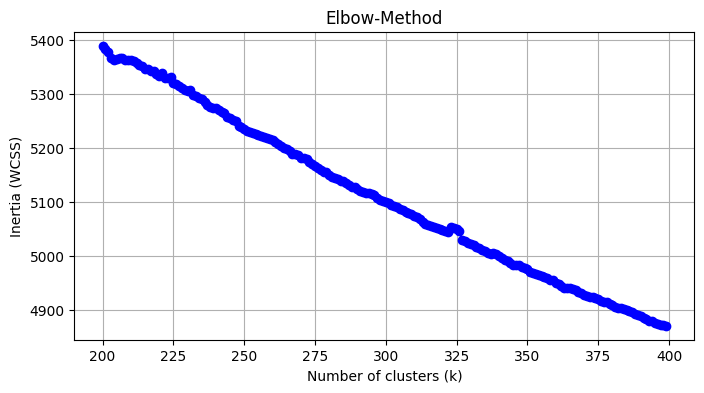

In [ ]:

# Plot the elbow graph
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow-Method')
plt.grid(True)
plt.show()

#### **Choosing k = 40**
Forty clusters is a practical compromise: it can capture a variety of exam topics without overwhelming granularity.

In [ ]:
from sklearn.cluster import KMeans
import tqdm as tqdm
from tqdm import tqdm

n_clusters = 40

print(f"Starting KMeans clustering with {n_clusters} clusters...")

kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)

# tqdm for progress
with tqdm(total=100, desc="KMeans Clustering Progress") as pbar:
    kmeans.fit(X_tfidf)
    pbar.update(100) # Update to 100% when fitting is complete

print("KMeans clustering finished.")

# Assign cluster labels
cluster_labels = kmeans.labels_


Starting KMeans clustering with 40 clusters...


KMeans Clustering Progress: 100%|██████████| 100/100 [00:01<00:00, 52.96it/s]

KMeans clustering finished.


### 2D visualization using TSNE dimensionallity reduction

In [ ]:
from sklearn.manifold import TSNE
import numpy as np # Import numpy
import plotly.express as px # Import plotly
import pandas as pd # Import pandas for DataFrame operations

X_tfidf_dense = np.asarray(X_tfidf.todense())

# perplexity is a hyperparameter that can be tuned (default is 30)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tfidf_dense)

# Prepare data for plotting
# Create df_plot from df_docs filtering for 'middle' subset
df_plot = df_docs[df_docs['subset'] == 'middle'].copy()
df_plot['tsne_x'] = X_tsne[:, 0]
df_plot['tsne_y'] = X_tsne[:, 1]
df_plot['cluster'] = cluster_labels

# Function to get top words for each cluster
def get_top_words_per_cluster(X_tfidf_matrix, cluster_labels, vocab, n_words=10):
    """
    Gets the top words for each cluster based on TF-IDF scores.

    Args:
        X_tfidf_matrix: The sparse TF-IDF matrix (for the middle subset).
        cluster_labels: The KMeans cluster labels.
        vocab: The vocabulary from the TF-IDF vectorizer.
        n_words: The number of top words to retrieve per cluster.

    Returns:
        A dictionary where keys are cluster IDs and values are strings
        of the top words.
    """
    cluster_top_words = {}

    # Create a pandas DataFrame from the sparse matrix for easy grouping
    # Use the cluster labels as the index for grouping
    tfidf_df = pd.DataFrame.sparse.from_spmatrix(X_tfidf_matrix)
    tfidf_df['cluster'] = cluster_labels

    # Compute the mean TF-IDF score for each word within each cluster
    centroids = tfidf_df.groupby('cluster').mean()

    for cluster_id in sorted(tfidf_df['cluster'].unique()):
        if cluster_id == -1: # Handle potential noise cluster if using DBSCAN or similar
            continue
        # Get the row corresponding to the current cluster centroid
        centroid = np.asarray(centroids.loc[cluster_id].values)

        # Get indices of top words in the centroid
        top_word_indices = np.argsort(centroid)[-n_words:][::-1]

        # Get the words
        top_words = [vocab[i] for i in top_word_indices]
        cluster_top_words[cluster_id] = ', '.join(top_words)
    return cluster_top_words


cluster_top_words = get_top_words_per_cluster(X_tfidf, cluster_labels, vocab)

# Add top words to the dataframe for hover information
df_plot['top_words'] = df_plot['cluster'].map(cluster_top_words)

fig = px.scatter(
    df_plot,
    x='tsne_x',
    y='tsne_y',
    color=df_plot['cluster'].astype(str),
    hover_name='docno',    # Display docno on hover
    hover_data={'cluster': True, 'top_words': True, 'tsne_x': False, 'tsne_y': False}, # Display cluster and top words on hover
    title=f'Document Clusters (TSNE, k={n_clusters}) with Top Words on Hover'
)

fig.update_layout(showlegend=True)
fig.show()

#### What We Learned (and What Didn’t Work)
- **Some Thematic Groupings Emerge**  
  Clusters whose top TF-IDF words include terms like _“computer, phone, internet”_ (communication/technology) or _“play, music, sport”_ (leisure) clearly map to reading topics.  
- **Many Clusters Lack Coherence**  
  Other clusters center on generic words (“people, thing, day”) or even colour words, reflecting stylistic or frequency artifacts rather than genuine subject‐matter groupings.  

- **t-SNE Visualization Shows Blurry Boundaries**  
  When we project document centroids into 2D, clusters overlap heavily, indicating that our simple sparse representation fails to separate many topics cleanly.

> **Conclusion:** While TF-IDF + K-Means surfaces some meaningful themes, its reliance on bag-of-words limits semantic nuance—resulting in ill‐defined clusters.


### Contextual Topic Modeling with Sentence Embeddings and BERTopic

To overcome these limitations, we will:
1. **Generate Contextual Embeddings**  
   Use a pretrained SentenceTransformer to embed each article so that meaning beyond surface word co-occurrence is captured.  




---



# Sentence Embeddings

## 1. Semantic search (FAISS)

### preliminary steps

In [ ]:
df_docs.head()

,docno,article,subset,split
0,0,Last week I talked with some of my students ab...,high,train
1,1,"YUZHOU, HENAN -An accident in a central China ...",high,train
2,2,Understanding the process of making career cho...,high,train
3,3,Astronauts on shorter shuttle missions often w...,high,train
4,4,Dogs have long been used to find explosives an...,high,train


In [ ]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 841.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [ ]:
import re
url_re = re.compile(r'''
    (?:                                  # ← no capture, choose one branch
      (?i:                               # 1) scheme branch, case-insensitive here
        https?\s*:\s*(?:/\s*){2}         #   http://  or  https://
      | www\s*\.\s*                     # 2) www. prefix
      )
      (?:                                # domain = one or more “words”
        [A-Za-z0-9-]+
        (?:[\s\.]+[A-Za-z0-9-]+)*        #   separated by spaces or dots
      )
      (?:\s*\.\s*                        # final “.TLD”
         (?:Com|Org|[a-z]{2,6})             #   either literal “Com” or 2–6 lowercase letters
      )
    )
    (?:\s*[/?#]\s*\S*)?                  # optional path/query, allowing space before /
    (?![a-z0-9])                      # don’t run into following word
''', re.VERBOSE)

email_re = r"[\w\.-]+@([\w-]+\.)+[\w-]{2,4}"
phone_re = r"[\+]?[(]?[0-9]{3}[)]?[-\s\.]*[(]?[0-9]{3}[)]?[-\s\.]*[0-9]{4,6}"

pattern = r"[^a-z0-9\s.,;:!?'\-\"()&]" # semantically relevant

def preprocess_text(text):
    # Remove emails
    text = re.sub(email_re, '', text)
    # Remove URLs
    text = re.sub(url_re, '', text)
    # Remove phone numbers
    text = re.sub(phone_re, '', text)
    # Mask dates (simple pattern matching)
    #text = re.sub(r'\b(?:\d{1,2}[/\-]\d{1,2}[/\-]\d{2,4}|\d{4})\b', '[DATE]', text)
    # Mask standalone numbers
    #text = re.sub(r'\b\d+\b', '[NUMBER]', text)
    text = text.lower()
    text = re.sub(r'(.\n|\n)', '. ', text)
    # remove double occurence of punctuation
    # remove semantically irrelevant characters
    text = re.sub(pattern, '', text)
    text = re.sub(r"([.,;:!?'\-\"()\]&])\1+", r"\1", text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

articles_cleaned = df_docs['article'].apply(preprocess_text).tolist()
print(len(articles_cleaned))

27931


In [ ]:
df_docs['articles'] = articles_cleaned

In [ ]:
word_avg_high = df_docs[df_docs['subset'] == 'high']['article'].apply(lambda x: len(x.split())).mean()
word_avg_middle = df_docs[df_docs['subset'] == 'middle']['article'].apply(lambda x: len(x.split())).mean()

word_avg_high, word_avg_middle

(np.float64(307.692141208157), np.float64(197.9880935705281))

In [ ]:
!pip install bertopic[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 3.5 MB/s eta 0:00:00


In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 40.2 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')  # Sentence Transformer model tuned for semantic search

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Encode the cleaned articles
article_embeddings = model.encode(
    articles_cleaned,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True  # Returns embeddings as a NumPy array
)

Batches:   0%|          | 0/873 [00:00<?, ?it/s]

In [ ]:
article_embeddings_search.shape

(27931, 384)

### Building FAISS Index for retrieval

In [ ]:
import faiss
import numpy as np

# Build & save FAISS index
# uses inner prod on L2-normalized vectors for cosine sim

# Normalize embeddings for cosine similarity
faiss.normalize_L2(article_embeddings_search)

# Initialize the FAISS index
dimension = article_embeddings_search.shape[1]
index = faiss.IndexFlatIP(dimension)  # Inner Product for cosine similarity

# Add embeddings to the index
index.add(article_embeddings_search)

# Save
faiss.write_index(index, 'faiss_index.idx')


In [ ]:
def semantic_search(query: str, top_k: int = 5) -> pd.DataFrame:
    """Return top_k rows of df_docs most similar to query."""
    q = preprocess_text(query)
    q_emb = model.encode([q], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)
    hits = indices[0].tolist()
    scores = scores[0].tolist()
    results = df_docs.iloc[hits].copy()
    results['score'] = scores
    return results

In [ ]:
query = 'Why do people spend time on their phone?'

results = semantic_search(query, top_k=10)
results[['docno', 'subset', 'score', 'article']]

,docno,subset,score,article
24562,22496,middle,0.722952,"Next time you're in a public place, take a loo..."
23439,21373,middle,0.692137,A study found most people use their smart phon...
14956,14956,high,0.672175,A recent report says we spend an average of tw...
22531,20465,middle,0.635540,If you need to call your parents but your phon...
20509,27286,high,0.630544,It's enough to give anyone an earache. Women s...
19777,26554,high,0.618019,Owning a smartphone may not be as smart as you...
25743,23677,middle,0.617641,Once upon a time if we wanted to make a phone ...
4540,4540,high,0.612552,Cellphone feels like a part of your body? A gl...
1420,1420,high,0.611240,Owning a smartphone may not be as smart as you...
5344,5344,high,0.602666,"When you get in your car, you reach for it. Wh..."


In [ ]:
query = 'Why do people spend time on their phone?'
query = 'Dangers of internet'
query = 'historical events'
query = 'crime time'
query = 'why broccoli is secretly evil'
query = 'how to train your dragon in school'
query = 'what happens if robots get bored'
results = semantic_search(query, top_k=10)
results[['docno', 'subset', 'score', 'article']]

,docno,subset,score,article
13229,13229,high,0.598477,A robot is a computer-controlled machine that ...
27846,27846,middle,0.571098,If someone asks you to draw a picture of a rob...
1788,1788,high,0.564178,"Robots are smart. With their computer brains, ..."
10487,10487,high,0.562882,"There are robots all around us, Some do very c..."
17607,17607,high,0.559757,It's a safe bet that a robot made your car and...
27754,27754,middle,0.542697,"Robots are supposed to run on batteries, right..."
15468,15468,high,0.538114,It's a safe bet that a robot made your car and...
24053,21987,middle,0.530119,Robots have come a long way since 15th century...
27388,26343,middle,0.527744,People began to make robots about several hund...
24497,22431,middle,0.525632,"In some science fiction movies, evil robots re..."




---



## 2. Topic Modelling (BERTopic)

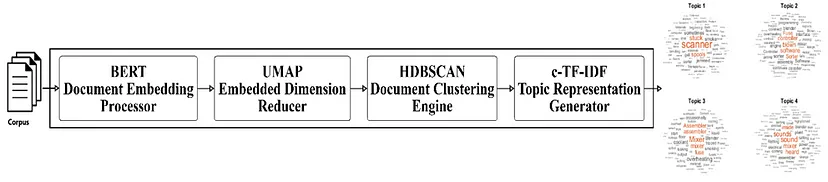

### Contextual Topic Modeling with BERTopic

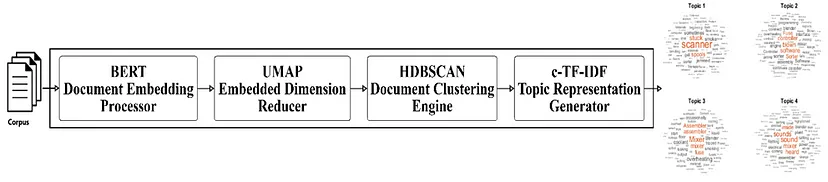

**BERTopic** is a modern topic-modeling framework (with some very nice built-in visualization methods) that leverages transformer-based sentence embeddings, density-based clustering, and class-based TF-IDF to extract coherent topics from text. Its core pipeline consists of four stages:

1. **Embedding Generation**  
   A pretrained SentenceTransformer encodes each document into a dense, fixed-length vector that captures contextual and semantic information beyond simple bag-of-words.  
2. **Dimensionality Reduction (UMAP)**  
   UMAP projects these high-dimensional embeddings into a lower-dimensional manifold, preserving both local and global structure while reducing noise.  
3. **Clustering (HDBSCAN)**  
   HDBSCAN identifies dense regions in the reduced space, automatically determining the number of topics and labeling each embedding either to a cluster (topic) or as noise.  
4. **Topic Representation (c-TF-IDF / KeyBERTInspired)**  
   For each cluster, BERTopic uses a class-based TF-IDF variant to surface the most representative n-grams. Here, we enhance this with the `KeyBERTInspired` model, which selects topic descriptors directly from the embedding space for improved semantic relevance.

---

#### Custom Configuration (Final Setup after Trial and Error)


- **Embedding Model: `all-MiniLM-L6-v2`**  
  We choose this lightweight SentenceTransformer for its balance of speed and embedding quality, enabling rapid experimentation on our ~28K-passage corpus without significant loss in semantic fidelity, Although it has a maximum token length of 256 (broadly we can assume 1 word ~ 1.3 token), this tradeoff is acceptable, since it didn't really affect our model negatively.

- **Biasing Toward Larger, Coherent Topics**  
  We deliberately tuned UMAP and HDBSCAN to favor a smaller number of well-populated clusters while preserving interpretability:
  - **UMAP**  
    - `n_neighbors=30` and `n_components=8` retain enough global structure to form broad topic regions without fragmenting them.  
  - **HDBSCAN**  
    - `min_cluster_size=40` ensures each topic has a substantial document base, reducing spurious tiny clusters.  
    - `min_samples=8` balances between discovering tight, pure clusters and maintaining coverage across the dataset.  


- **Topic Representation: `KeyBERTInspired`**  
  Instead of vanilla c-TF-IDF, we use a representation model inspired by KeyBERT to select topic keywords directly from our embedding space. This produces more semantically cohesive and human-interpretable topic labels.


### preliminary steps

In [ ]:
from sentence_transformers import SentenceTransformer

model_mini = SentenceTransformer('all-MiniLM-L12-v2')

In [ ]:
# Encode the cleaned articles
article_embeddings_mini = model_mini.encode(
    articles_cleaned,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True  # Returns embeddings as a NumPy array
)

Batches:   0%|          | 0/873 [00:00<?, ?it/s]

Batches:   0%|          | 0/873 [00:00<?, ?it/s]

### 2.1. BERTopic default configuration

In [ ]:
# Get topic information
topic_info = topic_model_mini.get_topic_info()
topic_info.head()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,10605,-1_was_he_my_she,"[was, he, my, she, her, his, and, the, to, had]","[one fine day, an old couple around the age of..."
1,0,427,0_man_boy_he_him,"[man, boy, he, him, his, farmer, old, said, as...",[a young man woke up one morning under a bridg...
2,1,353,1_dogs_dog_cat_cats,"[dogs, dog, cat, cats, pet, pets, animal, owne...",[is your family interested in buying a dog? a ...
3,2,313,2_parents_child_children_teenagers,"[parents, child, children, teenagers, their, l...",[i don't like my parents. they always tell me ...
4,3,273,3_my_me_was_had,"[my, me, was, had, him, told, car, asked, man,...","[my name is sam. i joined a club called ""passi..."


In [ ]:
  topic_model_mini.visualize_topics()


In [ ]:
  topic_model_mini.visualize_barchart()


### 2.2 Customizing Hbdscan and finetune topic representation using KeyBertInspired model

In [ ]:
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# Load the embedding model used for precomputing embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Initialize the KeyBERTInspired representation model
representation_model = KeyBERTInspired()

umap_model = UMAP(n_neighbors=30, n_components=8, metric='cosine', low_memory=False)
hdbscan_model = HDBSCAN(min_cluster_size=40, min_samples=8, metric='euclidean', prediction_data=True)

# Initialize BERTopic with the embedding and representation models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    representation_model=representation_model,
    verbose=True
)

# Fit the model using raw documents and precomputed embeddings
topics, probs = topic_model.fit_transform(articles_cleaned, article_embeddings_mini)

2025-05-24 11:30:48,258 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-24 11:31:27,690 - BERTopic - Dimensionality - Completed ✓
2025-05-24 11:31:27,693 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-24 11:31:31,916 - BERTopic - Cluster - Completed ✓
2025-05-24 11:31:31,932 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-24 11:33:01,189 - BERTopic - Representation - Completed ✓


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def assign_representative_docs(topic_model, docs, embeddings):
    topic_reps = {}
    for topic in set(topic_model.topics_):
        if topic == -1:
            continue
        indices = [i for i, t in enumerate(topic_model.topics_) if t == topic]
        if not indices:
            continue
        topic_embeds = np.array([embeddings[i] for i in indices])
        centroid = topic_embeds.mean(axis=0, keepdims=True)
        sims = cosine_similarity(centroid, topic_embeds).flatten()
        best_idx = indices[np.argmax(sims)]
        topic_reps[topic] = docs[best_idx]

    topic_model.representative_docs_ = topic_reps
assign_representative_docs(topic_model, articles_cleaned, article_embeddings_mini)


In [ ]:
topic_model.get_topic_info()[:20]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,13137,-1_life_very_what_you,"[life, very, what, you, more, have, about, wor...",NaN
1,0,656,0_diet_eat_meals_eating,"[diet, eat, meals, eating, obesity, meal, obes...",as a nation we are becoming more aware of the ...
2,1,418,1_cars_vehicles_car_driving,"[cars, vehicles, car, driving, roads, vehicle,...","""everybody in this city wants a car, and i'm n..."
3,2,396,2_pets_dogs_dog_pet,"[pets, dogs, dog, pet, animals, animal, wolf, ...",people sometimes like to read stories of dogs ...
4,3,394,3_farmer_horse_cow_bird,"[farmer, horse, cow, bird, he, very, tree, gol...",there was once a farmer. his land was hilly an...
5,4,360,4_teacher_sister_student_family,"[teacher, sister, student, family, lucy, lily,...",my name is bill. i'm an english boy. i'm in no...
6,5,353,5_reading_readers_reader_read,"[reading, readers, reader, read, books, writin...",are you a bookworm? is your head stuck in a bo...
7,6,338,6_english_language_languages_speak,"[english, language, languages, speak, learners...",english is a very interesting language. it has...
8,7,313,7_nasa_astronauts_moon_astronaut,"[nasa, astronauts, moon, astronaut, mars, spac...",the journey to the moon had been the first ste...
9,8,277,8_sleep_sleeping_slept_nap,"[sleep, sleeping, slept, nap, asleep, bedtime,...","judging from recent surveys, most experts in s..."


> **Column guide:**  
> - **Topic ID**: BERTopic’s cluster label (–1 is reserved for outliers, as in 'Not belonging to any cluster').  
> - **Count**: Number of documents assigned to the topic.  
> - **Representation Keywords**: The top words defining each topic, as refined by the representation model.  
> - **Sample Excerpt**: Representative documents illustrating topic context, as in documents that are closest to the identified centroid.

In [ ]:
  topic_model.visualize_topics()


In [ ]:
topic_model.visualize_barchart()

In [ ]:
topic_model.visualize_hierarchy()

#### What We Learn

- **Clear, Domain-Specific Topics** like “diet & obesity”, “cars & driving”, “NASA & astronauts” show the model’s ability to recover concrete reading themes. Moreover, the hierarchical topic representation highlights natural merge points—e.g. clusters around “climate”, “greenhouse”, “pollution”, “warming” (22, 76) sit close together in the hierarchy, suggesting they belong to a broader “climate change” theme. The inter-cluster distances also align with our semantic interpretations, confirming that related topics are appropriately proximate.

- A very large **noise cluster (–1)** indicates that many passages don’t fit neatly into any one topic under our current settings, suggesting either further parameter tuning or post-hoc filtering/merging is required to handle these outliers effectively.  


### Revisiting K-Means with Sentence Embeddings

Our HDBSCAN-based BERTopic pipeline, while powerful at discovering dense, variable‐sized clusters, proved highly sensitive to parameter tweaks—small changes either yielded an explosion of tiny topics or collapsed everything into just a couple of groups. This instability, coupled with a large noise cluster, motivated us to try a more stable, fixed-k approach using **K-Means** on contextual embeddings:

1. **Dimensionality Reduction with PCA**  
   Instead of UMAP, we apply PCA (`n_components=5`) to our SentenceTransformer embeddings. PCA offers deterministic projections and faster fitting, ensuring reproducible downstream clustering while still capturing most of the variance in five dimensions.

2. **K-Means for Controlled Cluster Count**  
   By specifying `n_clusters=40`, we regain direct control over the number of topics, avoiding the unpredictability of HDBSCAN’s density thresholds. K-Means’ spherical clusters complement our PCA-reduced embedding space.

3. **CountVectorizer + Class-TF-IDF**  
   We replace c-TF-IDF with a pipeline using `CountVectorizer(stop_words="english")` to build document-term counts, followed by `ClassTfidfTransformer(reduce_frequent_words=True)` to weight terms per topic. This setup parallels BERTopic’s usual representation but is matched to our new clustering algorithm.

4. **Integration in BERTopic**  
   By passing `umap_model=pca_model` and `hdbscan_model=kmeans_model` into BERTopic, we leverage its end-to-end topic extraction logic—topic assignment, term ranking, and probability estimation—while swapping in our stable PCA+K-Means core.

> **Why this helps:**  
> - **Stability:** K-Means guarantees exactly 40 topics, eliminating the risk of collapse or runaway fragmentation.  
> - **Reproducibility:** PCA’s deterministic nature combined with K-Means’ fixed k yields consistent results across runs.  
> - **Interpretability:** A controlled topic count and familiar clustering paradigm make it easier to compare against our original TF-IDF + K-Means baseline and fine-tune topic granularity.  

#### Topic Model with Kmeans (k=40)

In [ ]:
from bertopic import BERTopic
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

# Define PCA for dimensionality reduction
pca_model = PCA(n_components=5, random_state=42)

# Define KMeans clustering model
kmeans_model = KMeans(n_clusters=40, init='k-means++', n_init=10, max_iter=300, random_state=42)


# Define CountVectorizer to remove English stopwords
vectorizer_model = CountVectorizer(stop_words="english")

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


# Initialize BERTopic with custom components
topic_model = BERTopic(
    umap_model=pca_model,
    hdbscan_model=kmeans_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    verbose=True
)

# Fit the model using raw documents and precomputed embeddings
topics, probs = topic_model.fit_transform(articles_cleaned, article_embeddings_mini)


2025-05-24 13:40:16,277 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-24 13:40:16,444 - BERTopic - Dimensionality - Completed ✓
2025-05-24 13:40:16,446 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-24 13:40:17,952 - BERTopic - Cluster - Completed ✓
2025-05-24 13:40:17,962 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-24 13:40:26,481 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model_2.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,1011,0_health_cancer_risk_diet,"[health, cancer, risk, diet, sleep, weight, ex...",sometimes it may seem difficult to improve our...
1,1,961,1_city_tea_cities_london,"[city, tea, cities, london, water, people, wor...",it is exciting to visit different places. as y...
2,2,919,2_hotel_city_festival_tour,"[hotel, city, festival, tour, museum, island, ...",one might expect that the ever-growing demands...
3,3,904,3_people_english_american_world,"[people, english, american, world, women, lang...","now,i'll tell you something about the internet..."
4,4,893,4_dogs_water_cats_animals,"[dogs, water, cats, animals, body, people, col...",answers to life can be found in everyday event...
5,5,873,5_men_brain_women_human,"[men, brain, women, human, people, work, resea...",discoveries in science and technology are thou...
6,6,873,6_energy_water_food_carbon,"[energy, water, food, carbon, oil, cars, gas, ...",there is a forgotten player in the global effo...
7,7,854,7_internet_technology_computer_computers,"[internet, technology, computer, computers, co...","cyberspace, data superhighway, multimedia, for..."
8,8,849,8_scientists_animals_species_earth,"[scientists, animals, species, earth, fish, bi...",dr charlotte uhlenbroek recently returned to l...
9,9,832,9_world_said_years_people,"[world, said, years, people, moon, famous, fil...",it's really a miracle . mr. clarke works in ne...


# Comparing uncovered Topics by Class (Highschool vs Middleschool)

In [ ]:
topic_model_2.visualize_topics()

In [ ]:
topic_model_2.visualize_barchart()

In [ ]:
topic_model_2.visualize_hierarchy()

As a reminder, the Highschool subset makes up ~75 % of the corpus

### A: HDBScan (Top 20)

In [ ]:

topics_per_class = topic_model.topics_per_class(articles_cleaned, classes=df_docs['subset'].to_list())

fig = topic_model.visualize_topics_per_class(
    topics_per_class,
    top_n_topics=20,
    normalize_frequency=True,
    custom_labels=True
)
fig.show()

2it [00:06,  3.36s/it]


### B: Kmeans (Top 20)

In [ ]:
topics_per_class = topic_model_2.topics_per_class(articles_cleaned, classes=df_docs['subset'].to_list())

fig = topic_model_2.visualize_topics_per_class(
    topics_per_class,
    top_n_topics=20,
    normalize_frequency=True,
    custom_labels=True
)
fig.show()

2it [00:22, 11.33s/it]


In [1]:
# prompt: can i also print the topics per class in a table

import pandas as pd
topics_per_class_kmeans = topic_model.topics_per_class(articles_cleaned, classes=df_docs['subset'].to_list())

# Create a DataFrame for easier viewing
topics_per_class_df = pd.DataFrame(topics_per_class_kmeans)

# Display the topics per class in a table
print("\nTopics per Class (KMeans - Normalized Frequency):")
print(topics_per_class_df.pivot(index='Topic', columns='Class', values='Frequency'))


NameError: name 'topic_model' is not defined

In [ ]:
topics_per_class = topic_model_2.topics_per_class(articles_cleaned, classes=df_docs['subset'].to_list())

fig = topic_model.visualize_topics_per_class(
    topics_per_class,
    top_n_topics=20,
    normalize_frequency=True,
    custom_labels=True
)
fig.show()

2it [00:09,  4.78s/it]
